In [16]:
df <- read.csv("data/fluview_clean/ilinet_final.csv")
library(ggplot2)
library(forecast)
source("df.R")
source("find_best_rmse.r")
# head(df)
data <- split_data(df$percent_weighted_ili,remove.missing = T)
# data$ts_obj,data$train,data$holdout

stl_obj <- stl(data$train,t.window = NULL,s.window = "periodic")

# plot(response[,"remainder"])
autoplot(response) + 
  ggtitle("STL Decomposition of ILI") +
  theme_minimal()
# plot(response, main="Seasonal Component of ILI Total", ylab="Seasonal Component", xlab="Time")
# plot(main="Seasonal Component of Non-ILI Total", ylab="Seasonal Component", xlab="Time")



ERROR: [1m[33mError[39m in `autoplot()`:[22m
[1m[22m[33m![39m Objects of class [34m<list>[39m are not supported by autoplot.
[36mℹ[39m Have you loaded the required package?


Now we are goint to 

In [ ]:
source("stl.r")

In [ ]:
# model <- extract_stl_components(stl_obj)

# perhaps it is better to have a rolling forecast on less data so we update faster

stl_fc <- stl_rolling_forecast(data$train, data$holdout, s.window = "periodic")
print(stl_fc$rmse)
residuals_train <- stl_fc$residuals_train
residuals_holdout <- stl_fc$residuals_holdout
data<- split_data(c(residuals_train, residuals_holdout),start = start(data$train), frequency = frequency(data$train))
plot(data$holdout, type = "l", main = "Residuals from STL Rolling Forecast", ylab = "Residual", xlab = "Time")
# find_best_rmse_out_of_sample(data)


In [ ]:
initial_orders = list(ar = c(1, 0, 0), i = c(0, 1, 1), ma = c(0, 0, 2))
source("find_best_rmse.r")
find_best_rmse_out_of_sample(data$ts_obj, initial_orders = initial_orders, perturbation = 1, iterations = 1,inverse_transformation = function(x)x )

In [ ]:
# Alternative is doing one more stl on the residuals at each time and then doing an arima on that so lets implement that quickly.

residuals_data<- split_data(c(residuals_train, residuals_holdout),start = start(data$train), frequency = 19)
stl_residulas_fc <- stl_rolling_forecast(residuals_data$train, residuals_data$holdout, s.window = "periodic")
stl_residulas_fc$rmse

In [ ]:


# Function to perform 1-step rolling forecast with ARIMA on STL residuals
stl_arima_rolling_forecast <- function(train_data, holdout_data, s.window = "periodic", t.window = NULL, 
                                       arima_order = c(1, 0, 1), seasonal_arima = c(0, 0, 0)) {
  forecasts <- numeric(length(holdout_data))
  residuals <- numeric(length(holdout_data))
  current_train <- train_data
  
  # Extract frequency from original training data
  freq <- frequency(train_data)
  
  for (i in seq_along(holdout_data)) {
    # Recreate time series with proper frequency
    if (s.window == "periodic") {
      current_train_ts <- ts(current_train, frequency = freq)
    } else {
      current_train_ts <- current_train
    }
    
    # Fit STL on current training set
    stl_fit <- stl(current_train_ts, s.window = s.window, t.window = t.window)
    
    # Extract components
    components <- extract_stl_components(stl_fit)
    
    # Fit ARIMA on the remainder component
    arima_fit <- arima(components$remainder, order = arima_order, seasonal = list(order = seasonal_arima),include.mean = F)

    # Get 1-step ahead forecast for trend and seasonal (use last values)
    last_trend <- tail(components$trend, 1)
    seasonal_comp <- components$seasonal[length(components$seasonal) - freq + 1] 
    arima_forecast <- predict(arima_fit, n.ahead = 1)$pred[1]
    forecast_value <- last_trend + seasonal_comp + arima_forecast
    forecasts[i] <- forecast_value
    residuals[i] <- holdout_data[i] - forecast_value
    current_train <- c(current_train, holdout_data[i])
  }
  
  return(list(
    forecasts = forecasts,
    residuals = residuals,
    actual = holdout_data,
    rmse = sqrt(mean(residuals^2))
  ))
}
data<- split_data(percentage_transform(df$percent_weighted_ili),remove.missing = T)
order <- list(arima_order = c(3, 0, 2), seasonal_arima = c(0, 0, 0))
bestrmse<- Inf
for(i in 1:100){
  new_order <- perturb_orders(order, perturbation = 1)
  result <- stl_arima_rolling_forecast(data$train, data$holdout, s.window = "periodic", t.window = NULL, 
                                       arima_order = new_order$arima_order, seasonal_arima = new_order$seasonal_arima)
  print(paste("Best RMSE:",bestrmse ,result$rmse))
  print(paste(new_order$arima_order, new_order$seasonal_arima))

  if(result$rmse < bestrmse){
    bestrmse <- result$rmse
    order<- new_order
    best_result <- result
  }
  
}





ts.plot(result$actual,result$forecasts, col = c("blue","red"), main = "Actual vs Forecasted ILI", ylab = "ILI Percentage", xlab = "Time")


In [ ]:
result$residuals


In [ ]:

# Arima(data$train,order=c(1,1,2),seasonal = list(order = c(2,0,0), period = 52))



	Box-Ljung test

data:  residuals
X-squared = 190.81, df = 52, p-value < 2.2e-16


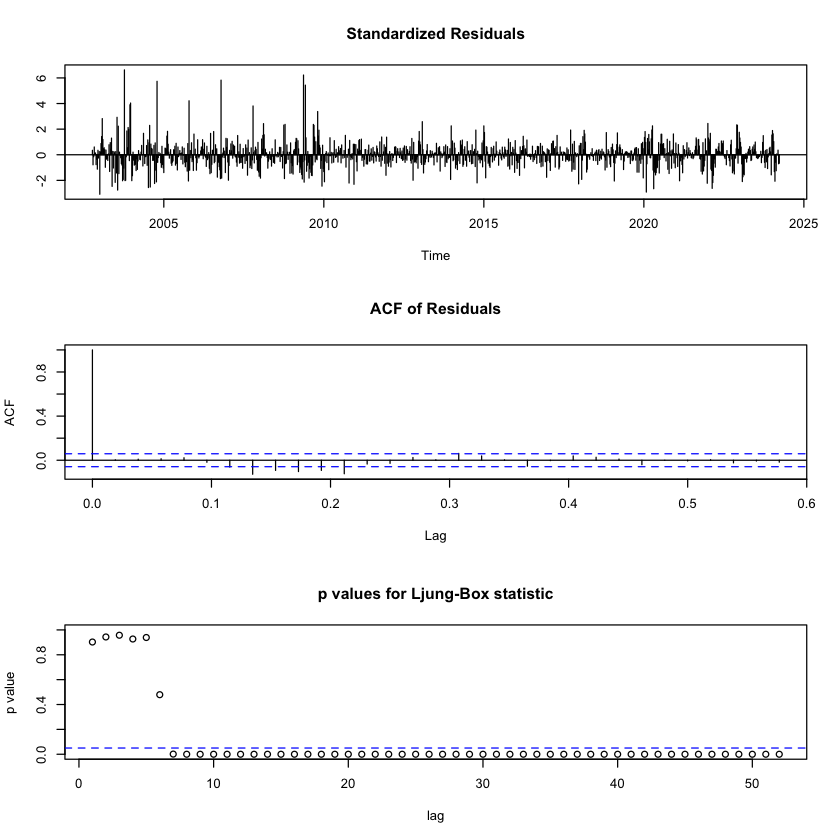

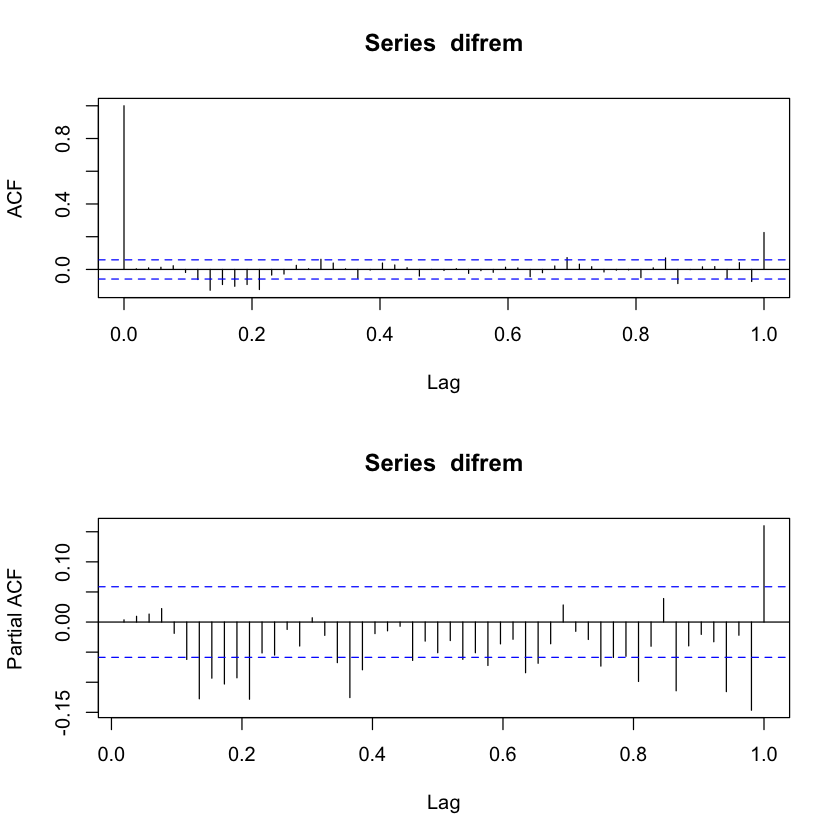

In [39]:
source("stl.r")
source("residual_checks.R")
data <-  split_data(df$age_5_24,remove.missing = T)
# stl_obj <- stl_rolling_forecast(data$train,data$holdout,t.window = NULL,s.window = "periodic")
rem <- extract_stl_components(stl(ts(as.numeric(data$train),start = start(data$train),frequency = 19),t.window = NULL,s.window = "periodic"))$remainder
remrem <- extract_stl_components(stl(ts(as.numeric(rem),start = start(data$train),frequency = 52), t.window = NULL, s.window = "periodic"))$remainder

# plot(remrem[1:208],type="l", main="STL Remainder Component", ylab="Remainder", xlab="Time")
arimaob <- auto.arima(remrem, seasonal = F, stepwise = T, approximation = T)

#     # stl_obj <-auto.arima(stl(data$train,t.window = NULL,s.window = "periodic"))
model_diagnostics(arimaob,residuals(arimaob))
par(mfrow=c(2,1))
difrem <-residuals(arimaob)
acf(difrem,lag.max = 52)
pacf(difrem,lag.max = 52)
par(mfrow=c(1,1))

In [ ]:
# we need to unify the stl errors!
residuals_holdout<- stl_obj$residuals_holdout
residuals_train <- stl_obj$residuals_train
remainders <- ts(c(residuals_holdout, residuals_train), start = start(data$train), frequency = frequency(data$train))
# we can take the remainder and

In [ ]:
# expm1(results$best_fc)
# logp1(results$best_fc)

# residuals_holdout

STL+MSARIMA rolling: 5 %

In [ ]:
object<- split_data(df$age_5_24,remove.missing = T)
# stlarima_obj
plot(stlarima_obj$actual-stlarima_obj$forecasts)
par(mfrow=c(1,2))
acf(stlarima_obj$actual-stlarima_obj$forecasts,lag.max = 52)
pacf(stlarima_obj$actual-stlarima_obj$forecasts,lag.max = 52)
par(mfrow=c(1,1))
# ts.plot(stlarima_obj$forecasts-stlarima_obj$actual, col = c("red","blue"), main = "STL+ARIMA Forecast vs Actual", ylab = "ILI Percentage", xlab = "Time")
# expm1(object$holdout)-stlarima_obj$forecasts
# # sqrt(mean((expm1(object$holdout)-stlarima_obj$forecasts)^2))

## STL on each variable

In [50]:
source("stl.r")
source("transformations.r")
source("df.R")

column_names <- c("ilitotal", "age_0_4", "age_5_24", "age_25_64", "age_65")
column_names_2 <- c("age_25_49", "age_50_64")
all_columns <- c(column_names, column_names_2)

df <- read.csv("data/fluview_clean/ilinet_final.csv")
old_df <- read.csv("data/fluview_clean/ilinet_clean.csv")


stl_rmse_results <- data.frame(variable = all_columns, rmse = NA_real_)
stl_forecasts_list <- list()


for (i in column_names) {
  tryCatch({
    data <- split_data(df[[i]], remove.missing = TRUE)
    response <- stl_rolling_forecast(data$train, data$holdout, 
                                     s.window = "periodic", t.window = NULL, 
                                     transformation = expm1)
    
    stl_rmse_results$rmse[stl_rmse_results$variable == i] <- response$rmse
    stl_forecasts_list[[i]] <- response$forecasts
    
    cat("\n", i, " - RMSE:", response$rmse, "\n")
  }, error = function(e) {
    cat("\nError processing", i, ":", conditionMessage(e), "\n")
  })
}


for (i in column_names_2) {

  tryCatch({
    
    data <- split_data(old_df[[i]][628:nrow(old_df)], start = c(2009, 40))
    print(data)
    response <- stl_rolling_forecast(data$train, data$holdout, 
                                     s.window = "periodic", t.window = NULL, 
                                     transformation = expm1)
    
    stl_rmse_results$rmse[stl_rmse_results$variable == i] <- response$rmse
    stl_forecasts_list[[i]] <- response$forecasts
    
    cat("\n", i, " - RMSE:", response$rmse, "\n")
  }, error = function(e) {
    cat("\nError processing", i, ":", conditionMessage(e), "\n")
  })
}

# Print summary
cat("\n=== STL Rolling Forecast Results ===\n")
print(stl_rmse_results)

# Convert forecasts list to data frame (find max length to pad with NA if needed)
max_forecast_length <- max(sapply(stl_forecasts_list, length))
stl_forecasts_df <- data.frame(matrix(NA, nrow = max_forecast_length, ncol = length(stl_forecasts_list)))
colnames(stl_forecasts_df) <- names(stl_forecasts_list)

for (i in names(stl_forecasts_list)) {
  stl_forecasts_df[[i]] <- c(stl_forecasts_list[[i]], rep(NA, max_forecast_length - length(stl_forecasts_list[[i]])))
}

# # Write results to CSV files
write.csv(stl_forecasts_df, "./forecasting/stl_forecasts.csv", row.names = FALSE)
write.csv(stl_rmse_results, "./forecasting/stl_rmse.csv", row.names = FALSE)

cat("\nForecasts saved to ./forecasting/stl_forecasts.csv\n")
cat("RMSE results saved to ./forecasting/stl_rmse.csv\n")


$train
Time Series:
Start = c(2009, 40) 
End = c(2024, 10) 
Frequency = 52 
  [1]  8554 10271 12399 12166 10250  8174  6163  4378  4259  3588  3249  2677
 [13]  3202  3333  2793  2693  2560  2581  2644  2649  2943  2763  2660  2468
 [25]  2097  1954  1718  1572  1461  1435  1385  1363  1364  1235  1212  1081
 [37]   978   882   862   816   819   759   805   839   809   883   811  1019
 [49]  1076  1061  1291  1269  1677  1779  1898  1754  1981  1956  2327  2043
 [61]  2440  2511  2847  3433  4455  4455  4220  5095  5952  6536  6812  7257
 [73]  6425  4869  3939  3265  2551  2244  1985  1574  1505  1324  1305  1254
 [85]  1131  1045  1013  1037   911   870   750   823   756   733   667   635
 [97]   704   767   814   887   904  1022  1126  1253  1765  1777  1763  1773
[109]  1957  2072  2166  1803  2059  1938  2077  2068  2315  2342  2319  2247
[121]  2303  2415  2582  2937  3009  3141  2832  3321  2822  2485  2306  2109
[133]  1990  1831  1728  1559  1547  1461  1276  1281  1150  1119 

## STL+ARIMA

In [202]:
# STL+ARIMA for ilitotal only
# Perturb orders to find optimal model, save forecasts and RMSE

source("stl.R")
source("find_best_rmse.r")
source("df.R")
source("transformations.r")

df <- read.csv("data/fluview_clean/ilinet_final.csv")

# Load ilitotal data
data <- split_data(df$ilitotal, remove.missing = TRUE)

# Initial ARIMA order for the remainder component
initial_order <- list(ar = c(1, 1, 0), i = c(0, 0, 1), ma = c(3, 2, 0))

best_rmse <- Inf
best_order <- initial_order
best_result <- NULL

cat("=== STL+ARIMA Model Selection for ilitotal ===\n")
cat("Perturbations: 50\n\n")
current_order<- initial_order
# Run 50 perturbations
for (iteration in 1:50) {
  # Perturb the order
  
  # Fit STL+ARIMA with current order
  tryCatch({
    result <- stl_arima(
      "ilitotal",
      orders=current_order,
      s.window = "periodic", 
      t.window = NULL
    )
    
    current_rmse <- result$rmse
    
    # Update best if improved
    if (current_rmse < best_rmse) {
      best_rmse <- current_rmse
      best_order <- current_order
      best_result <- result
      
      cat("Iteration", iteration, "- NEW BEST RMSE:", round(best_rmse, 4), 
          "- Order: AR(", paste(best_order$ar, collapse = ","), 
          ") I(", paste(best_order$i, collapse = ","),
          ") MA(", paste(best_order$ma, collapse = ","), ")\n")
    } else if (iteration %% 10 == 0) {
      cat("Iteration", iteration, "- Current RMSE:", round(current_rmse, 4), "\n")
    }
    
    # Update initial order for next perturbation
    initial_order <- current_order
    current_order <- perturb_orders(initial_order, perturbation = 1)
    
  }, error = function(e) {
    cat("Iteration", iteration, "- Error:", conditionMessage(e), "\n")
  })
}



STL+MSARIMA rolling: 2 %

In [ ]:
# ts.plot(hubahuba$forecasts)
source("arima_1_step_rmse.R")
model <- arima(data$train, order = c(2, 0, 2), seasonal = list(order = c(1, 1, 0), period = 52))
hubahuba <- one_step_forecast_error(data$train, data$holdout, model)
hubahuba$rmse


ERROR: Error in optim(init[mask], armafn, method = optim.method, hessian = TRUE, : initial value in 'vmmin' is not finite


agg_record_12a12319eeb 
                     2

              G         H
 [1,] 1.0000000 1.0000000
 [2,] 1.0037676 1.0028919
 [3,] 0.9829797 0.9812544
 [4,] 0.9737058 0.9713976
 [5,] 1.0034611 1.0008341
 [6,] 0.9901723 0.9867877
 [7,] 1.0265597 1.0223027
 [8,] 1.0037681 0.9987451
 [9,] 1.0482289 1.0422627
[10,] 1.0076002 1.0013989
[11,] 1.0418233 1.0349736
[12,] 0.9763833 0.9697046
[13,] 1.0137123 1.0057819
[14,] 0.9958542 0.9878924
[15,] 0.9953986 0.9866037
[16,] 0.9364529 0.9281310
[17,] 1.0042553 0.9943653
[18,] 0.9573635 0.9478055
[19,] 1.0106015 0.9993263
[20,] 0.9742473 0.9626952
[21,] 0.9867425 0.9744433
[22,] 1.0148872 1.0012055
[23,] 0.9689448 0.9552615
[24,] 1.0610078 1.0445553
[25,] 0.9684530 0.9530772
[26,] 1.0450690 1.0271237
[27,] 0.9832244 0.9659347
[28,] 0.9995967 0.9810395
[29,] 1.0099955 0.9903896
[30,] 1.0604762 1.0386829
[31,] 1.0301959 1.0082735
[32,] 1.0161547 0.9937861
[33,] 1.0387089 1.0148017
[34,] 1.0267832 1.0025888
[35,] 1.0065187 0.9820373
[36,] 0.9896696 0.9649039
[37,] 0.9898641 0.9642201
[38,] 1.0358

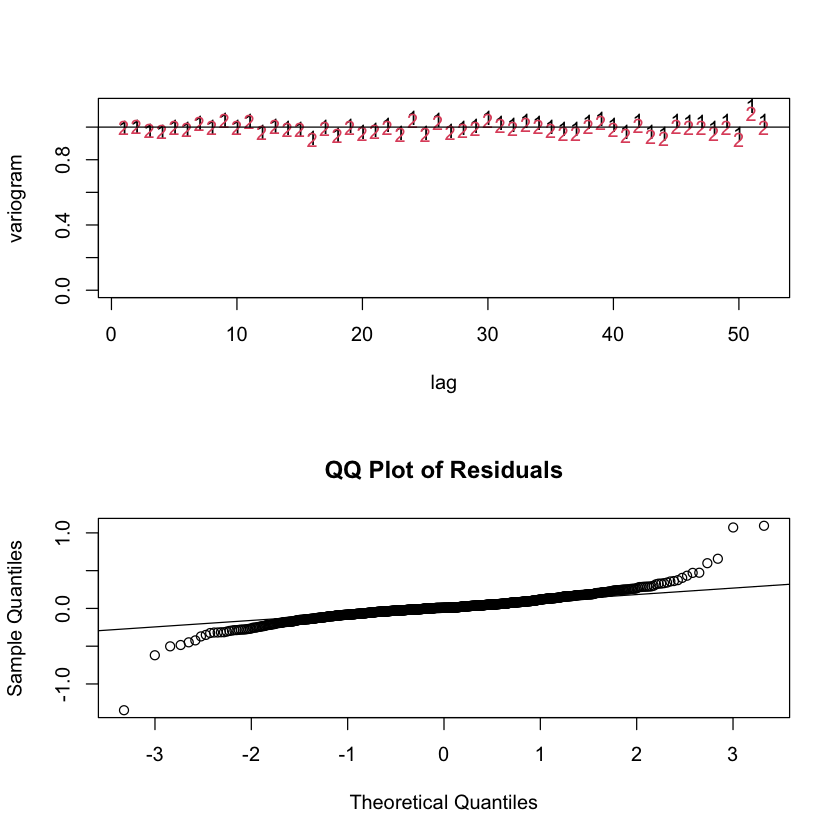


	Box-Ljung test

data:  residuals
X-squared = 61.388, df = 52, p-value = 0.1749


agg_record_12a12319eeb 
                     2

              G         H
 [1,] 1.0000000 1.0000000
 [2,] 1.0037676 1.0028919
 [3,] 0.9829797 0.9812544
 [4,] 0.9737058 0.9713976
 [5,] 1.0034611 1.0008341
 [6,] 0.9901723 0.9867877
 [7,] 1.0265597 1.0223027
 [8,] 1.0037681 0.9987451
 [9,] 1.0482289 1.0422627
[10,] 1.0076002 1.0013989
[11,] 1.0418233 1.0349736
[12,] 0.9763833 0.9697046
[13,] 1.0137123 1.0057819
[14,] 0.9958542 0.9878924
[15,] 0.9953986 0.9866037
[16,] 0.9364529 0.9281310
[17,] 1.0042553 0.9943653
[18,] 0.9573635 0.9478055
[19,] 1.0106015 0.9993263
[20,] 0.9742473 0.9626952
[21,] 0.9867425 0.9744433
[22,] 1.0148872 1.0012055
[23,] 0.9689448 0.9552615
[24,] 1.0610078 1.0445553
[25,] 0.9684530 0.9530772
[26,] 1.0450690 1.0271237
[27,] 0.9832244 0.9659347
[28,] 0.9995967 0.9810395
[29,] 1.0099955 0.9903896
[30,] 1.0604762 1.0386829
[31,] 1.0301959 1.0082735
[32,] 1.0161547 0.9937861
[33,] 1.0387089 1.0148017
[34,] 1.0267832 1.0025888
[35,] 1.0065187 0.9820373
[36,] 0.9896696 0.9649039
[37,] 0.9898641 0.9642201
[38,] 1.0358

agg_record_12a12319eeb 
                     2

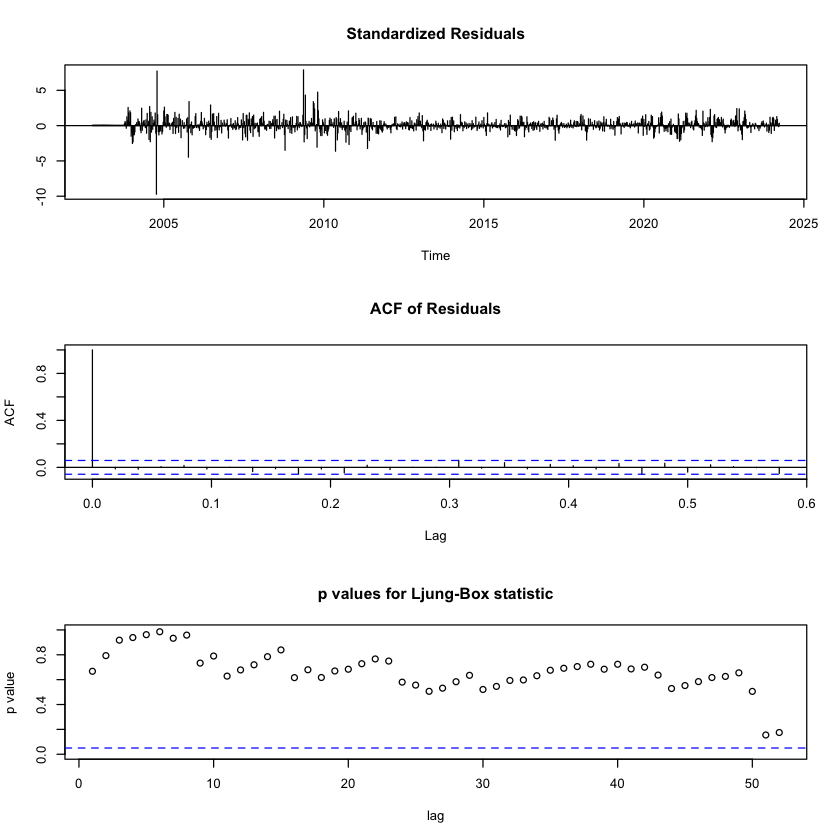

In [ ]:
source("residual_checks.r")

save_img(function() { periodogram(data$train,main="ili_total")},"Periodogram_ilitoal",width = 600,height=600)
# save_img(
residuals_diagnostics(model, residuals(model))
# ,"ARIMA(2,0,2)(1,1,0)_{52}",height=600,width=600)
save_img(function(){model_diagnostics(model,residuals(model))},"Model_diagnostics_arima",width=600,height = 600)

save_img(function(){
    par(mfrow=c(3,1))
    qqnorm(residuals(model), main="QQ Plot of Residuals of ARIMA(2,0,3)(3,1,1)_{52}")
    qqline(residuals(model))
    variogram(residuals(model),lagmax=52, iprint=T)
    pacf(residuals(model), main=paste("PACF of Residuals for ARIMA(2,0,3)(3,1,1)_{52}"),lag.max = 52)
    par(mfrow=c(1,1))
},"variogram_qqnorm_residuals_arima",height=600,width=600)
# model_diagnostics(model,residuals(model))
# Box-Ljung test

# data:  residuals
# X-squared = 61.388, df = 52, p-value = 0.1749

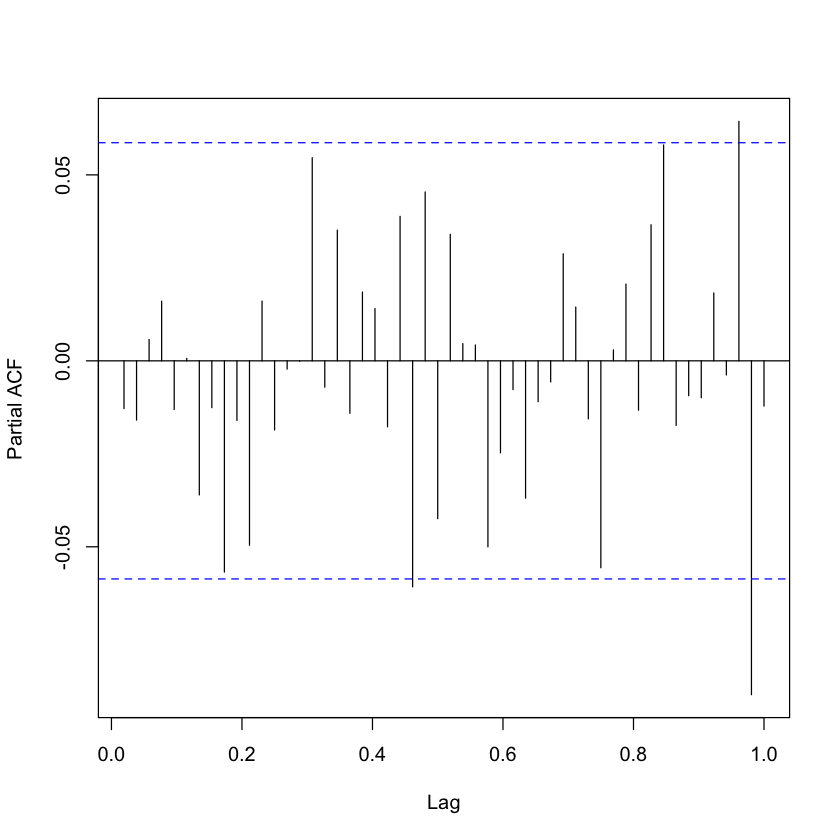

In [ ]:
pacf(residuals(model),main="",lag.max = 52)

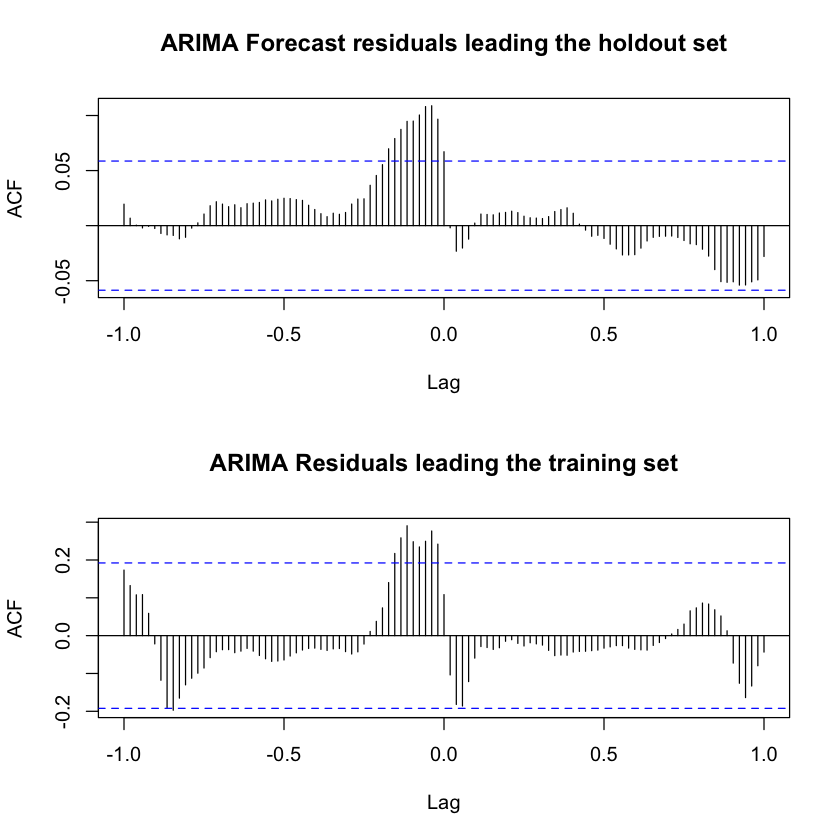

In [204]:
# sqrt(mean(((exp(data$holdout)-1)-hubahuba$forecasts)^2))
# plot(residuals(model))
# save_img(function(){
par(mfrow=c(2,1))
ccf(x=residuals(model),y= exp(data$train),lag.max=52,main="ARIMA Forecast residuals leading the holdout set")
ccf(x=(exp(data$holdout)-1)-hubahuba$forecasts,y=(exp(data$holdout)-1),lag.max=52, main="ARIMA Residuals leading the training set")
par(mfrow=c(1,1))
# },"arima_residuals_leading",height=600,width=600)

In [166]:

# Print final results
cat("\n=== Final STL+ARIMA Results for ilitotal ===\n")
cat("Best RMSE:", round(best_rmse, 4), "\n")
cat("Best AR order:", paste(best_order$ar, collapse = ","), "\n")
cat("Best I order:", paste(best_order$i, collapse = ","), "\n")
cat("Best MA order:", paste(best_order$ma, collapse = ","), "\n")
source("arima_1_step_rmse.R")


# Save forecasts and RMSE to CSV
if (!is.null(best_result)) {
  # Create data frame with forecasts
  stlarima_forecast_df <- data.frame(
    actual = best_result$actual,
    forecast = best_result$forecasts,
    residuals = best_result$residuals
  )
  
  # Save forecasts
  write.csv(stlarima_forecast_df, "./forecasting/stlarima_forecasts.csv", row.names = FALSE)
  
  # Save model parameters and RMSE
  stlarima_summary <- data.frame(
    variable = "ilitotal",
    ar = paste(best_order$ar, collapse = ","),
    i = paste(best_order$i, collapse = ","),
    ma = paste(best_order$ma, collapse = ","),
    rmse = best_rmse
  )
  
  write.csv(stlarima_summary, "./forecasting/stlarima_summary.csv", row.names = FALSE)
   stl_reponse <- stl_rolling_forecast(data$train, data$holdout, s.window = "periodic", t.window = NULL, transformation = expm1)

}


STL is rolling:  100 %

In [182]:
cat("\n=== Final STL+ARIMA Results for ilitotal ===\n")
cat("Best RMSE:", round(best_rmse, 4), "\n")
cat("Best AR order:", paste(best_order$ar, collapse = ","), "\n")
cat("Best I order:", paste(best_order$i, collapse = ","), "\n")
cat("Best MA order:", paste(best_order$ma, collapse = ","), "\n")

 
  print(c("STL RMSE:", stl_reponse$rmse))
  # Plot results
  save_img(plotfcn = function() {
  ts.plot(best_result$actual,best_result$forecasts,stl_reponse$forecasts,hubahuba$forecasts, type = "l", col =c("black", "red","blue","darkgreen"), lty = c(1, 2,2,2),lwd=2,
       main = "Forecast ili total: STL, STL+MS ARIMA, ARIMA ",
       ylab = "Ili_total", xlab = "Holdout Step")
  
  legend("topleft", legend = c("Actual", "STL+MS ARIMA(1,0,3)(0,1,0)_{19}(1,0,2)_{52}","STL","ARIMA(2,0,3)(3,1,1)_{52}"), col = c("black", "red","blue","darkgreen"), lty = c(1, 2,2,2))
  }, name = "stl_stlarima_forecast_plot", width = 800, height = 600)
  



=== Final STL+ARIMA Results for ilitotal ===
Best RMSE: 9685.038 
Best AR order: 1,1,0 
Best I order: 0,0,1 
Best MA order: 3,2,0 
[1] "STL RMSE:"        "12592.9257883209"


agg_record_12a126122da02 
                       2